# Benchmarking Model Inference usage

In this notebook we will measure the VRAM usage due to inference of various classification and some object dection models.


In [1]:
# display information about available GPU devices
!nvidia-smi

Thu Oct 23 23:47:32 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install nvidia-ml-py

In [3]:
# %pip install ultralytics

In [4]:
from pynvml import *
from functools import lru_cache
import csv
import tensorflow as tf
from tensorflow.keras.layers import RandomHeight, RandomWidth
from tensorflow.keras.preprocessing import image
import numpy as np
import time
from tensorflow.keras.models import load_model
from multiprocessing import Process, Queue, Event
import os
import psutil
import pandas as pd
import matplotlib.pyplot as plt


2025-10-23 23:47:39.403131: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761263259.696787      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761263259.765581      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
@lru_cache()
def is_gpu_available() -> bool:
    try:
        nvmlInit()
        nvmlShutdown()
        return True
    except Exception:
        return False

In [6]:
def initialize_nvml(gpu_index=0):
    """Initialize NVML and return handle to GPU, or None if unavailable"""
    try:
        nvmlInit()
        count = nvmlDeviceGetCount()
        if count == 0 or gpu_index >= count:
            print("No valid GPU found for NVML.")
            return None
        return nvmlDeviceGetHandleByIndex(gpu_index)
    except NVMLError as e:
        print(f"Failed to initialize NVML: {e}")
        return None

In [7]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    print(f"Found {len(gpus)} GPU(s)")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth set on GPUs")
    except RuntimeError as e:
        print(f"Could not set memory growth: {e}")
else:
    print("No GPU available, using CPU")

Found 2 GPU(s)
Memory growth set on GPUs


In [8]:
def close_nvml():
    """Shutdown NVML."""
    try:
        nvmlShutdown()
    except Exception as e:
        print(f"Failed to close NVML: {e}")

In [9]:
def get_pid_vram_used_bytes(pid=None, handle=None):
    """Return TensorFlow GPU memory usage instead of NVML"""
    try:
        gpus = tf.config.list_physical_devices('GPU')
        if not gpus:
            return 0
        # Sum VRAM across all GPUs
        total_vram = 0
        for gpu in gpus:
            mem = tf.config.experimental.get_memory_info(gpu.name)
            total_vram += mem['current']
        return total_vram
    except Exception:
        return 0


In [10]:
def bytes2mb(x):
    """Convert bytes to MB"""
    return x / (1024**2)

In [11]:
def bytes2human(number: int, decimal_unit: bool = True) -> str:
    symbols = ['K', 'M', 'G', 'T', 'P', 'E', 'Z', 'Y']
    symbol_values = [(symbol, 1000**(i+1) if decimal_unit else (1 << (i+1) * 10))
                     for i, symbol in enumerate(symbols)]

    for symbol, value in reversed(symbol_values):
        if number >= value:
            suffix = "B" if decimal_unit else "iB"
            return f"{float(number)/value:.2f}{symbol}{suffix}"

    return f"{number} B"

In [12]:
def get_pid_ram_used_bytes(pid: int) -> int:
    """Return RAM usage in bytes for a given process ID."""
    try:
        process = psutil.Process(pid)
        return process.memory_info().rss  # Resident Set Size (RAM in bytes)
    except psutil.NoSuchProcess:
        return 0

In [13]:
def get_tf_vram_bytes(gpu_index: int = 0) -> float:
    """Return current VRAM usage in bytes for TensorFlow on the given GPU."""
    import tensorflow as tf
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if not gpus or gpu_index >= len(gpus):
        return 0
    mem_info = tf.config.experimental.get_memory_info(f'GPU:{gpu_index}')
    print(mem_info)
    return mem_info['current'] 


In [14]:
def get_total_vram_used_bytes(handle) -> int:
    """Get the total used VRAM on a GPU device."""
    try:
        info = nvmlDeviceGetMemoryInfo(handle)
        print(info)
        return info.used  # This returns the total VRAM used on the GPU
    except Exception:
        return 0

In [15]:
def get_vram_usage_by_pid(pid):
    # This is a workaround that gets total VRAM instead of per-PID.
    # It is the most reliable method in this environment.
    try:
        device_count = nvmlDeviceGetCount()
        for i in range(device_count):
            handle = nvmlDeviceGetHandleByIndex(i)
            info = nvmlDeviceGetMemoryInfo(handle)
            return info.used
    except NVMLError as e:
        print(f"NVML Error: {e}")
        return 0

In [16]:
def _memory_profiler(pid: int, stop_event: Event,
                     ram_queue: Queue, vram_queue: Queue,
                     time_interval: float = 0.05, gpu_index: int = 0) -> None:
    """Monitor RAM + VRAM usage of a process"""
    print(f"Measuring RAM + VRAM usage of process {pid} started.")
    
    handle = initialize_nvml(gpu_index)
    if handle is None:
        print("VRAM monitoring disabled (NVML unavailable).")

    while not stop_event.is_set():
        # RAM
        ram_queue.put(get_pid_ram_used_bytes(pid))
        vram_queue.put(get_vram_usage_by_pid(pid))
        time.sleep(time_interval)

    close_nvml()
    print("Memory profiler stopped.")

In [17]:
class SkProfiler:
    """
    Context manager to monitor RAM and VRAM usage during a code block.

    Usage:
        with SkProfiler("inference", "profile.csv"):
            # your code here

    Args:
        name (str): Name of the memory scope.
        result_file (str, optional): Path to the file where results will be saved.
        pid (int, optional): Process ID to monitor. Defaults to current process.
        time_interval (float, optional): Sampling interval in seconds.
    """

    def __init__(self, name: str, result_file: str = None,
                 pid: int = None, time_interval: float = 0.05, gpu_index: int = 0):
        self._name = name
        self._ram_queue = Queue(maxsize=100000)
        self._vram_queue = Queue(maxsize=100000)

        self._stop_event = Event()
        self._monitor_process: Optional[Process] = None
        self._result_file = result_file
        self._time_interval = time_interval
        self._gpu_index = gpu_index
        self._pid = pid

    def __enter__(self):
        """Start the memory profiler process."""
        pid = self._pid if self._pid else os.getpid()
        self._monitor_process = Process(
            target=_memory_profiler,
            args=(pid,
                  self._stop_event,
                  self._ram_queue,
                  self._vram_queue,
                  self._time_interval,
                  self._gpu_index)
        )
        self._monitor_process.start()
        return self 
    def record(self, label=None):
        """Record current RAM + VRAM usage manually."""
        ram = get_pid_ram_used_bytes(self._pid or os.getpid())
        handle = initialize_nvml()
        vram = get_pid_vram_used_bytes(self._pid or os.getpid(), handle) if handle else 0
        close_nvml()
        self._ram_queue.put(ram)
        self._vram_queue.put(vram)
        if label:
            print(f"[Profiler] {label}: RAM={bytes2mb(ram):.2f}MB, VRAM={bytes2mb(vram):.2f}MB")
            
    def __exit__(self, exception_type, exception_value, exception_traceback):
        """Stop the memory monitor process and write results to file if specified."""
        self._stop_event.set()  # Signal the monitor process to stop
        assert self._monitor_process is not None

        if self._monitor_process.is_alive():
            self._monitor_process.join(timeout=15)
            if self._monitor_process.is_alive():
                self._monitor_process.terminate()
                print("Warning: monitor process did not exit cleanly.")

        # Write results to CSV
        if self._result_file:
            with open(self._result_file, "w") as f:
                f.write("Time, RAM_usage, VRAM_usage\n")
                index = 0
                while not self._ram_queue.empty() or not self._vram_queue.empty():
                    ram = self._ram_queue.get() if not self._ram_queue.empty() else 0
                    vram = self._vram_queue.get() if not self._vram_queue.empty() else 0
                    f.write(f"{round(index*self._time_interval,2)},{bytes2mb(ram):.2f},{bytes2mb(vram):.2f}\n")
                    index += 1
      

In [18]:
def load_and_preprocess(img_path, target_size=(224, 224)):
    """
    Load an image from disk and preprocess it for model prediction.
    
    Args:
        img_path (str): Path to the image file.
        target_size (tuple): Image size expected by the model (height, width).
    
    Returns:
        np.ndarray: Preprocessed image ready for model.predict().
    """
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)  # Add batch dimension
    x = x / 255.0  # Normalize if your model expects [0,1]
    return x

In [19]:
def get_gpu_vram_bytes():
    """Return VRAM usage reported by TensorFlow for all GPUs"""
    try:
        total = 0
        gpus = tf.config.list_physical_devices('GPU')
        for gpu in gpus:
            mem_info = tf.config.experimental.get_memory_info(gpu.name)
            total += mem_info['current']  # bytes
        return total
    except Exception:
        return 0

In [20]:
# -------------------------------
# Prediction function
# -------------------------------
def predict_image(img_path, class_names, model, target_size=(400, 400)):
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0
    preds = model.predict(x)
    preds_percentage = preds * 100
    pred_class_index = np.argmax(preds_percentage[0])
    pred_class_name = class_names[pred_class_index]
    return pred_class_name, preds_percentage

In [21]:
def run_benchmark(model_path, image_paths, class_names, csv_file_name="mobilenet_benchmark.csv", batch_size=8):
    model = tf.keras.models.load_model(
            model_path,
            custom_objects={"RandomHeight": RandomHeight, "RandomWidth": RandomWidth}
        )
    print("Running inference and recording RAM + VRAM usage...")

    # --- Start profiler context ---
    with SkProfiler("mobilenet_benchmark", result_file=csv_file_name) as profiler:
        # Process in batches to allocate GPU memory efficiently
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i+batch_size]
            batch_images = np.concatenate(
                [load_and_preprocess(p, target_size=(400,400)) for p in batch_paths], axis=0
            )

            # --- Record memory BEFORE inference ---
            profiler.record(label=f"before_batch_{i//batch_size}")

            start_time = time.time()
            preds = model.predict(batch_images, verbose=0)
            end_time = time.time()

            # --- Record memory AFTER inference ---
            profiler.record(label=f"after_batch_{i//batch_size}")

            # Print per-image predictions
            for j, img_path in enumerate(batch_paths):
                predicted_class = class_names[np.argmax(preds[j])]
                print(f"Inference on {img_path} completed in {round((end_time - start_time)/len(batch_paths), 3)}s, "
                      f"predicted: {predicted_class}")


In [22]:
def run_benchmark_individual(model_path, image_paths, class_names, csv_file_name="individual_benchmark.csv"):
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={"RandomHeight": RandomHeight, "RandomWidth": RandomWidth}
    )
    print("Running inference and recording RAM + VRAM usage for individual images...")

    with SkProfiler("mobilenet_individual", result_file=csv_file_name) as profiler:
        for img_path in image_paths:
            # Load and preprocess a single image
            img = load_and_preprocess(img_path, target_size=(400, 400))
            
            # Record memory before this individual inference
            profiler.record(label=f"before_{os.path.basename(img_path)}")

            start_time = time.time()
            # Perform inference on the single image
            preds = model.predict(img, verbose=0)
            end_time = time.time()
            
            # Record memory after this individual inference
            profiler.record(label=f"after_{os.path.basename(img_path)}")

            predicted_class = class_names[np.argmax(preds)]
            print(f"Inference on {img_path} completed in {round(end_time - start_time, 3)}s, "
                  f"predicted: {predicted_class}")

In [23]:
def run_benchmark_keras(model_path, image_paths, class_names, csv_file_name):
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={"RandomHeight": RandomHeight, "RandomWidth": RandomWidth}
    )
    print(f"Running inference for Keras model: {os.path.basename(model_path)}")
    # if "mobilenet" in model_path.lower():
    #     target_size = (400, 400)
    # else:
    target_size = (400, 400)
        
    with SkProfiler(os.path.basename(model_path), result_file=csv_file_name) as profiler:
        for img_path in image_paths:
            img = load_and_preprocess(img_path, target_size=target_size)

            profiler.record(label=f"before_{os.path.basename(img_path)}")
            start_time = time.time()
            preds = model.predict(img, verbose=0)
            end_time = time.time()
            profiler.record(label=f"after_{os.path.basename(img_path)}")

            predicted_class = class_names[np.argmax(preds)]
            print(f"{os.path.basename(model_path)} | {img_path} | "
                  f"time: {round(end_time - start_time, 3)}s | pred: {predicted_class}")


In [24]:
# def run_benchmark_yolo(model_path, image_paths, csv_file_name):
#     model = YOLO(model_path)
#     print(f"Running inference for YOLO model: {os.path.basename(model_path)}")

#     with SkProfiler(os.path.basename(model_path), result_file=csv_file_name) as profiler:
#         for img_path in image_paths:
#             img = load_and_preprocess(img_path, target_size=(255, 255))

#             profiler.record(label=f"before_{os.path.basename(img_path)}")
#             start_time = time.time()
#             results = model.predict(img, verbose=False)
#             end_time = time.time()
#             profiler.record(label=f"after_{os.path.basename(img_path)}")

#             # Extract detected classes
#             preds = results[0].boxes.cls.cpu().numpy()
#             pred_classes = [model.names[int(c)] for c in preds] if len(preds) > 0 else ["None"]
#             print(f"{os.path.basename(model_path)} | {img_path} | "
#                   f"time: {round(end_time - start_time, 3)}s | pred: {pred_classes}")

In [25]:
# model_paths = [
#     "/kaggle/input/aisummit-mobilenet-tl/MobileNet.h5", 
#     "/kaggle/input/aisummit-resnet50-tl/ResNet50.h5", 
#     "/kaggle/input/aisummit-resnet101-tl/ResNet101.h5", 
#     "/kaggle/input/aisummit-efficientnetv2s-tl/EfficientNetV2S.h5",
#     "/kaggle/input/aisummit-efficientnetv2m-tl/EfficientNetV2M.h5",
#     "/kaggle/input/aisummit-yolo-v8/runs/detect/train/weights/best.pt",
#     "/kaggle/input/aisummit-yolo-11n/runs/detect/train/weights/best.pt"
    
# ]

model_paths = [
    "/kaggle/input/aisummit-efficientnetv2s-tl/EfficientNetV2S.h5",
    "/kaggle/input/aisummit-efficientnetv2m-tl/EfficientNetV2M.h5",
    "/kaggle/input/aisummit-mobilenet-tl/MobileNet.h5", 
    "/kaggle/input/aisummit-resnet50-tl/ResNet50.h5", 
    "/kaggle/input/aisummit-resnet101-tl/ResNet101.h5", 
    "/kaggle/input/aisummit-yolo-v8/runs/detect/train/weights/best.pt",
    "/kaggle/input/aisummit-yolo-11n/runs/detect/train/weights/best.pt",
    "/kaggle/input/aisummit-improvedyolov8n/runs/detect/train/weights/best.pt"
    
]

class_names = ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

image_paths = [
    "/kaggle/input/aisummit-mobilenet-tl/data/test//biological/biological_104.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/cardboard/cardboard_2026.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/metal/metal_1147.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/glass/glass_1681.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/paper/paper_1039.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/plastic/plastic_1057.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/cardboard/cardboard_1626.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/trash/trash_255.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/glass/glass_2375.jpg"
]

# run_benchmark(model_path, image_paths, class_names, "mobilenet_benchmark.csv")
# run_benchmark_individual(model_path, image_paths, class_names, "individual_benchmark.csv")

In [26]:
def benchmark_and_plot_models(model_paths, image_paths, class_names):
    """
    Run benchmarks on multiple models and plot VRAM usage per model.
    
    Args:
        model_paths (list): List of model file paths (.h5 or .pt)
        image_paths (list): List of image paths for inference
        class_names (list): List of class labels
    """
    colors = plt.get_cmap("tab10").colors

    for model_path in model_paths:
        model_name = os.path.basename(model_path)
        csv_file = f"{model_name}_benchmark.csv"
        
        # Run Keras benchmark
        if model_path.endswith(".h5"):
            run_benchmark_keras(model_path, image_paths, class_names, csv_file)
        
        # Optional: Add YOLO/PT benchmark here if needed
        # elif model_path.endswith(".pt"):
        #     run_benchmark_yolo(model_path, image_paths, class_names, csv_file)
        
        # Load benchmark CSV
        df = pd.read_csv(csv_file)
        
        # Clean columns
        df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
        df["vram_smooth"] = df["vram_usage"].rolling(window=3, min_periods=1).mean()
        df.loc[df.index[-1], "vram_smooth"] = 0
        
        # Reset time for clarity
        time_vals = df["time"] - df["time"].iloc[0]
        
        # Plot VRAM
        plt.figure(figsize=(12, 6))
        plt.plot(time_vals, df["vram_smooth"], linewidth=2.5, color=colors[0], label="VRAM Usage")
        plt.scatter(time_vals, df["vram_smooth"], s=30, alpha=0.6, color=colors[0])
        plt.title(f"VRAM Usage Over Time - {model_name}", fontsize=16, weight='bold')
        plt.xlabel("Time (s)", fontsize=14)
        plt.ylabel("VRAM Usage (MB)", fontsize=14)
        plt.tight_layout()
        plt.savefig(f"vram_usage_{model_name}.png", dpi=300)
        plt.show()

In [27]:
# benchmark_and_plot_models(model_paths, image_paths, class_names)

In [28]:
# Output directory for quantized models
os.makedirs("/kaggle/working/quantized_models", exist_ok=True)


# -----------------------------
# Function: Quantize Keras (.h5)
# -----------------------------
def quantize_h5_to_tflite(h5_path, save_dir="/kaggle/working/quantized_models"):
    model_name = os.path.splitext(os.path.basename(h5_path))[0]
    print(f"Quantizing {model_name}...")

    # Load the model
    # model = tf.keras.models.load_model(h5_path)
    model = tf.keras.models.load_model(
        h5_path,
        custom_objects={"RandomHeight": RandomHeight, "RandomWidth": RandomWidth}
    )
    # Create converter
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Apply post-training quantization (int8 dynamic range)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    # Convert
    tflite_quant_model = converter.convert()

    # Save
    out_path = os.path.join(save_dir, f"{model_name}_quant.tflite")
    with open(out_path, "wb") as f:
        f.write(tflite_quant_model)

    print(f"✅ Saved quantized {model_name} at {out_path}")



In [29]:
for path in model_paths:
    if path.endswith(".h5"):
        print(f"Path: {path}")
        quantize_h5_to_tflite(path)

Path: /kaggle/input/aisummit-efficientnetv2s-tl/EfficientNetV2S.h5
Quantizing EfficientNetV2S...


I0000 00:00:1761263277.575441      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1761263277.576223      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Saved artifact at '/tmp/tmpljmlfm27'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, None, None, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  135027796530704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027796525712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027796531088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027796531856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027796532432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027796530896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027796525136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027796532240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027796532816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027796533392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1350277965326

W0000 00:00:1761263364.415283      19 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1761263364.415360      19 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1761263364.809078      19 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


✅ Saved quantized EfficientNetV2S at /kaggle/working/quantized_models/EfficientNetV2S_quant.tflite
Path: /kaggle/input/aisummit-efficientnetv2m-tl/EfficientNetV2M.h5
Quantizing EfficientNetV2M...
Saved artifact at '/tmp/tmpo96u8gyo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, None, None, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  135027336403408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027336402256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027336404560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027336412624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027336411856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027336403984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027336402064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135027336412240: TensorSpec

...

✅ Saved quantized MobileNet at /kaggle/working/quantized_models/MobileNet_quant.tflite
Path: /kaggle/input/aisummit-resnet50-tl/ResNet50.h5
Quantizing ResNet50...
Saved artifact at '/tmp/tmpbwcto8z3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, None, None, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  135025365182480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135025365182864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135024850023056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135024850022096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135024850022288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135024850022864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135024850022480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135024850023248: TensorSpec(shape=(), dtype=tf.resource, nam

W0000 00:00:1761263563.721103      19 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1761263563.721136      19 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


✅ Saved quantized ResNet50 at /kaggle/working/quantized_models/ResNet50_quant.tflite
Path: /kaggle/input/aisummit-resnet101-tl/ResNet101.h5
Quantizing ResNet101...
Saved artifact at '/tmp/tmpp1qt82oj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, None, None, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  135025316776464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135025316777040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135025316777424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135025316778384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135025316778192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135025316777616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135025316778000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135025316777232: TensorSpec(shape=(), dtype=tf.resource, na

W0000 00:00:1761263630.741267      19 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1761263630.741297      19 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


✅ Saved quantized ResNet101 at /kaggle/working/quantized_models/ResNet101_quant.tflite


In [30]:
all_csvs = []
for model_path in model_paths:
    if model_path.endswith(".h5"):
        csv_file = f"{os.path.basename(model_path)}_benchmark.csv"
        run_benchmark_keras(model_path, image_paths, class_names, csv_file)
        all_csvs.append(csv_file)
    # elif model_path.endswith(".pt"):
    #     csv_file = f"{os.path.basename(model_path)}_benchmark.csv"
    #     run_benchmark_yolo(model_path, image_paths, csv_file)

Running inference for Keras model: EfficientNetV2S.h5
Measuring RAM + VRAM usage of process 19 started.
[Profiler] before_biological_104.jpg: RAM=4439.03MB, VRAM=0.00MB


I0000 00:00:1761263654.711970      67 cuda_dnn.cc:529] Loaded cuDNN version 90300


[Profiler] after_biological_104.jpg: RAM=4764.41MB, VRAM=0.00MB
EfficientNetV2S.h5 | /kaggle/input/aisummit-mobilenet-tl/data/test//biological/biological_104.jpg | time: 7.734s | pred: cardboard
[Profiler] before_cardboard_2026.jpg: RAM=4764.41MB, VRAM=0.00MB
[Profiler] after_cardboard_2026.jpg: RAM=4766.41MB, VRAM=0.00MB
EfficientNetV2S.h5 | /kaggle/input/aisummit-mobilenet-tl/data/test/cardboard/cardboard_2026.jpg | time: 0.115s | pred: trash
[Profiler] before_metal_1147.jpg: RAM=4766.41MB, VRAM=0.00MB
[Profiler] after_metal_1147.jpg: RAM=4766.53MB, VRAM=0.00MB
EfficientNetV2S.h5 | /kaggle/input/aisummit-mobilenet-tl/data/test/metal/metal_1147.jpg | time: 0.115s | pred: trash
[Profiler] before_glass_1681.jpg: RAM=4766.53MB, VRAM=0.00MB
[Profiler] after_glass_1681.jpg: RAM=4768.53MB, VRAM=0.00MB
EfficientNetV2S.h5 | /kaggle/input/aisummit-mobilenet-tl/data/test/glass/glass_1681.jpg | time: 0.107s | pred: trash
[Profiler] before_paper_1039.jpg: RAM=4768.53MB, VRAM=0.00MB
[Profiler] aft

In [31]:
for path in model_paths:
    if path.endswith(".h5"):
        model = tf.keras.models.load_model( path, custom_objects={"RandomHeight": RandomHeight, "RandomWidth": RandomWidth})
        total_params = model.count_params()
        trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
        non_trainable_params = sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])

        print(f"{path}:")
        print(f"  Total params: {total_params:,}")
        print(f"  Trainable params: {trainable_params:,}")
        print(f"  Non-trainable params: {non_trainable_params:,}")
        print("-" * 50)

/kaggle/input/aisummit-efficientnetv2s-tl/EfficientNetV2S.h5:
  Total params: 20,496,231
  Trainable params: 164,871
  Non-trainable params: 20,331,360
--------------------------------------------------
/kaggle/input/aisummit-efficientnetv2m-tl/EfficientNetV2M.h5:
  Total params: 53,315,259
  Trainable params: 164,871
  Non-trainable params: 53,150,388
--------------------------------------------------
/kaggle/input/aisummit-mobilenet-tl/MobileNet.h5:
  Total params: 3,360,967
  Trainable params: 132,103
  Non-trainable params: 3,228,864
--------------------------------------------------
/kaggle/input/aisummit-resnet50-tl/ResNet50.h5:
  Total params: 23,850,887
  Trainable params: 263,175
  Non-trainable params: 23,587,712
--------------------------------------------------
/kaggle/input/aisummit-resnet101-tl/ResNet101.h5:
  Total params: 42,921,351
  Trainable params: 263,175
  Non-trainable params: 42,658,176
--------------------------------------------------


In [32]:
%pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.4 MB/s eta 0:00:00
   ━━━━━

In [33]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [34]:
import cv2

def load_and_preprocess(path, target_size=(255, 255)):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Image not found or cannot be read: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # YOLO expects RGB
    img = cv2.resize(img, target_size)          # Resize to fixed target
    return img

In [35]:
def run_benchmark_yolo(model_path, image_paths, csv_file_name, model_name=None):
    model = YOLO(model_path)
    model_name = model_name or os.path.basename(model_path)  # fallback to filename
    print(f"Running inference for YOLO model: {model_name}")

    with SkProfiler(model_name, result_file=csv_file_name) as profiler:
        for img_path in image_paths:
            img = load_and_preprocess(img_path, target_size=(255, 255))

            profiler.record(label=f"before_{os.path.basename(img_path)}")
            start_time = time.time()
            results = model.predict(img, verbose=False)
            end_time = time.time()
            print(f"Image Path {os.path.basename(img_path)}")
            profiler.record(label=f"after_{os.path.basename(img_path)}")

            preds = results[0].boxes.cls.cpu().numpy()
            pred_classes = [model.names[int(c)] for c in preds] if len(preds) > 0 else ["None"]
            print(f"{model_name} | {img_path} | "
                  f"time: {round(end_time - start_time, 3)}s | pred: {pred_classes}")


In [36]:
for i, path in enumerate(model_paths):
    print(f"{i}: '{path}' -> basename: '{os.path.basename(path)}'")


0: '/kaggle/input/aisummit-efficientnetv2s-tl/EfficientNetV2S.h5' -> basename: 'EfficientNetV2S.h5'
1: '/kaggle/input/aisummit-efficientnetv2m-tl/EfficientNetV2M.h5' -> basename: 'EfficientNetV2M.h5'
2: '/kaggle/input/aisummit-mobilenet-tl/MobileNet.h5' -> basename: 'MobileNet.h5'
3: '/kaggle/input/aisummit-resnet50-tl/ResNet50.h5' -> basename: 'ResNet50.h5'
4: '/kaggle/input/aisummit-resnet101-tl/ResNet101.h5' -> basename: 'ResNet101.h5'
5: '/kaggle/input/aisummit-yolo-v8/runs/detect/train/weights/best.pt' -> basename: 'best.pt'
6: '/kaggle/input/aisummit-yolo-11n/runs/detect/train/weights/best.pt' -> basename: 'best.pt'
7: '/kaggle/input/aisummit-improvedyolov8n/runs/detect/train/weights/best.pt' -> basename: 'best.pt'


In [37]:
# Map full paths to custom model names

all_object_csvs = []
model_name_map = {
    "/kaggle/input/aisummit-yolo-v8/runs/detect/train/weights/best.pt": "yolo-v8n",
    "/kaggle/input/aisummit-yolo-11n/runs/detect/train/weights/best.pt": "yolo-11n",
    "/kaggle/input/aisummit-improvedyolov8n/runs/detect/train/weights/best.pt": "yolov8n-CBAM"
}

for model_path in model_paths:
    if model_path.endswith(".pt"):
        # Get model name from full path
        model_name = model_name_map.get(model_path, os.path.basename(model_path))
        csv_file = f"{model_name}_benchmark.csv"
        print(f"Model Name: {model_name}")
        run_benchmark_yolo(model_path, image_paths, csv_file, model_name=model_name)
        all_object_csvs.append(csv_file)


Model Name: yolo-v8n
Running inference for YOLO model: yolo-v8n
Measuring RAM + VRAM usage of process 19 started.
[Profiler] before_biological_104.jpg: RAM=4857.29MB, VRAM=0.00MB
Memory profiler stopped.
Image Path biological_104.jpg
[Profiler] after_biological_104.jpg: RAM=4901.66MB, VRAM=0.00MB
yolo-v8n | /kaggle/input/aisummit-mobilenet-tl/data/test//biological/biological_104.jpg | time: 1.083s | pred: ['plastic', 'biological']
[Profiler] before_cardboard_2026.jpg: RAM=4901.79MB, VRAM=0.00MB
Image Path cardboard_2026.jpg
[Profiler] after_cardboard_2026.jpg: RAM=4901.91MB, VRAM=0.00MB
yolo-v8n | /kaggle/input/aisummit-mobilenet-tl/data/test/cardboard/cardboard_2026.jpg | time: 0.012s | pred: ['cardboard']
[Profiler] before_metal_1147.jpg: RAM=4901.91MB, VRAM=0.00MB
Image Path metal_1147.jpg
[Profiler] after_metal_1147.jpg: RAM=4901.91MB, VRAM=0.00MB
yolo-v8n | /kaggle/input/aisummit-mobilenet-tl/data/test/metal/metal_1147.jpg | time: 0.009s | pred: ['metal']
[Profiler] before_glass_1

In [38]:
yolo_paths = [
    "/kaggle/input/aisummit-yolo-v8/runs/detect/train/weights/best.pt",
    "/kaggle/input/aisummit-yolo-11n/runs/detect/train/weights/best.pt",
    "/kaggle/input/aisummit-improvedyolov8n/runs/detect/train/weights/best.pt"
]

for model_path in yolo_paths:
    model = YOLO(model_path)

    total_params = sum(p.numel() for p in model.model.parameters())
    # Don’t rely on requires_grad (will be 0 if frozen after training)
    trainable_params = sum(p.numel() for p in model.model.parameters())
    non_trainable_params = total_params - trainable_params
    print(f"{model_path}:")
    print(f"  Total params: {total_params:,}")
    print(f"  Trainable params (all weights): {trainable_params:,}")
    print(f"  Non-trainable params: {non_trainable_params:,}")
    print("-" * 50)

/kaggle/input/aisummit-yolo-v8/runs/detect/train/weights/best.pt:
  Total params: 3,012,213
  Trainable params (all weights): 3,012,213
  Non-trainable params: 0
--------------------------------------------------
/kaggle/input/aisummit-yolo-11n/runs/detect/train/weights/best.pt:
  Total params: 2,591,205
  Trainable params (all weights): 2,591,205
  Non-trainable params: 0
--------------------------------------------------
/kaggle/input/aisummit-improvedyolov8n/runs/detect/train/weights/best.pt:
  Total params: 3,012,213
  Trainable params (all weights): 3,012,213
  Non-trainable params: 0
--------------------------------------------------


In [39]:
dfs = []
for csv in all_csvs:
    if os.path.exists(csv):
        df = pd.read_csv(csv)
        df["Model"] = os.path.basename(csv).replace("_benchmark.csv","")
        dfs.append(df)

final_df = pd.concat(dfs, ignore_index=True)
final_df.to_csv("all_models_benchmark.csv", index=False)

In [40]:
# Fix column names (remove spaces, lowercase, replace spaces with underscores)
final_df.columns = final_df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Cleaned columns:", final_df.columns.tolist())


Cleaned columns: ['time', 'ram_usage', 'vram_usage', 'model']


In [41]:
def mem_to_mb(x):
    x = str(x).strip()
    if x.endswith("gib"):
        return float(x.replace("gib","")) * 1024
    elif x.endswith("mib"):
        return float(x.replace("mib",""))
    elif x.endswith("kib"):
        return float(x.replace("kib","")) / 1024
    elif x.endswith("b"):
        return float(x.replace("b","")) / (1024**2)
    else:
        return float(x)

In [42]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()
print("Columns after cleaning:", df.columns.tolist())

Columns after cleaning: ['time', 'ram_usage', 'vram_usage', 'model']


In [43]:
# Convert VRAM column to MB if needed
vram_col = "vram_usage"
if df[vram_col].dtype == object:
    df[vram_col] = df[vram_col].apply(mem_to_mb)

# Strip model names and remove .h5


# ---------------------------
# Multi-model plotting function
# ---------------------------
def plot_all_models_vram(df, vram_col="vram_usage", smooth_window=3, save_path="all_models_vram.png"):
    fig, ax = plt.subplots(figsize=(14, 7))  # Use fig, ax for spines control

    # Generate unique colors for all models
    unique_models = df["model"].unique()
    colors = plt.cm.get_cmap("tab10", len(unique_models))

    for i, model in enumerate(unique_models):
        model_df = df[df["model"] == model].copy()
        # Apply rolling average
        model_df["VRAM_smooth"] = model_df[vram_col].rolling(window=smooth_window, min_periods=1).mean()
        model_df.loc[model_df.index[-1], "VRAM_smooth"] = 0

        model_label = model.replace(".h5", "")
        # Plot smoothed line
        ax.plot(model_df["time"], model_df["VRAM_smooth"], color=colors(i), label=f"{model_label}")
        # Plot original points lightly
        ax.scatter(model_df["time"], model_df[vram_col], color=colors(i), s=20, alpha=0.3)

        # Highlight peak
        peak_idx = model_df["VRAM_smooth"].idxmax()
        ax.scatter(model_df["time"][peak_idx], model_df["VRAM_smooth"][peak_idx],
                   color=colors(i), s=100, marker="x")

    # Dynamic y-axis
    min_mem = df[vram_col].min()
    max_mem = df[vram_col].max()
    margin = (max_mem - min_mem) * 0.1 + 1
    ax.set_ylim(min_mem - margin, max_mem + margin)

    # Labels and title
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("VRAM Usage (MB)")
    ax.set_title("VRAM Usage Over Time for Classification Models")

    # Legend
    ax.legend()

    # Remove grid (already removed)
    # ax.grid(True)

    # Remove top and left spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()



/tmp/ipykernel_19/662570015.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_models))


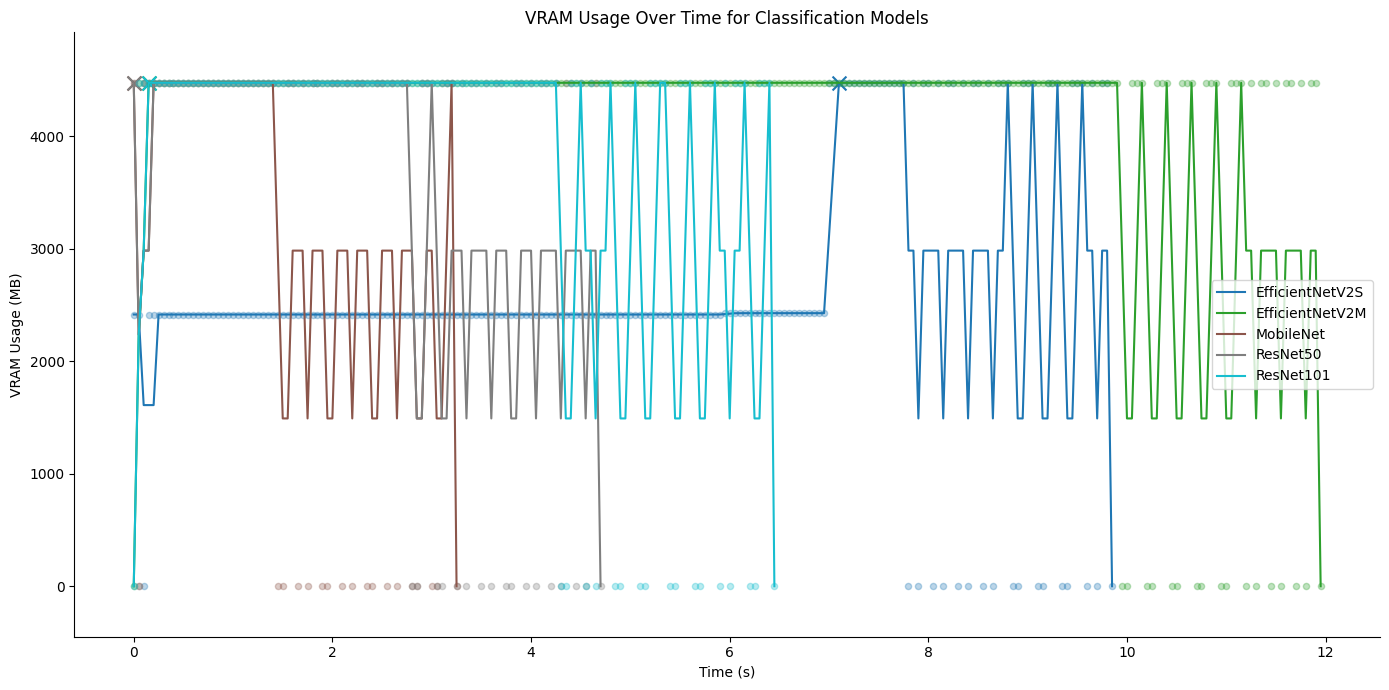

In [44]:
# # Usage
plot_all_models_vram(final_df)

In [45]:
all_object_csvs

['yolo-v8n_benchmark.csv',
 'yolo-11n_benchmark.csv',
 'yolov8n-CBAM_benchmark.csv']

In [46]:
object_dfs = []
for csv in all_object_csvs:
    if os.path.exists(csv):
        ob_df = pd.read_csv(csv)
        ob_df["Model"] = os.path.basename(csv).replace("_benchmark.csv","")
        object_dfs.append(ob_df)

final_df = pd.concat(object_dfs, ignore_index=True)
final_df.to_csv("all_models_benchmark.csv", index=False)

In [47]:
# Fix column names (remove spaces, lowercase, replace spaces with underscores)
final_df.columns = final_df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Cleaned columns:", final_df.columns.tolist())


Cleaned columns: ['time', 'ram_usage', 'vram_usage', 'model']


In [48]:
ob_df.columns = ob_df.columns.str.strip().str.replace(" ", "_").str.lower()
print("Columns after cleaning:", ob_df.columns.tolist())

Columns after cleaning: ['time', 'ram_usage', 'vram_usage', 'model']


In [49]:
# Convert VRAM column to MB if needed
vram_col = "vram_usage"
if ob_df[vram_col].dtype == object:
    ob_df[vram_col] = ob_df[vram_col].apply(mem_to_mb)

# Strip model names and remove .h5


# ---------------------------
# Multi-model plotting function
# ---------------------------
def plot_all_models_vram(ob_df, vram_col="vram_usage", smooth_window=3, save_path="obj_detection_models_vram.png"):
    fig, ax = plt.subplots(figsize=(14, 7))  # Use fig, ax for spines control

    # Generate unique colors for all models
    unique_models = ob_df["model"].unique()
    colors = plt.cm.get_cmap("tab10", len(unique_models))

    for i, model in enumerate(unique_models):
        model_df = ob_df[ob_df["model"] == model].copy()
        # Apply rolling average
        model_df["VRAM_smooth"] = model_df[vram_col].rolling(window=smooth_window, min_periods=1).mean()
        model_df.loc[model_df.index[-1], "VRAM_smooth"] = 0

        model_label = model.replace(".h5", "")
        # Plot smoothed line
        ax.plot(model_df["time"], model_df["VRAM_smooth"], color=colors(i), label=f"{model_label}")
        # Plot original points lightly
        ax.scatter(model_df["time"], model_df[vram_col], color=colors(i), s=20, alpha=0.3)

        # Highlight peak
        peak_idx = model_df["VRAM_smooth"].idxmax()
        ax.scatter(model_df["time"][peak_idx], model_df["VRAM_smooth"][peak_idx],
                   color=colors(i), s=100, marker="x")

    # Dynamic y-axis
    min_mem = ob_df[vram_col].min()
    max_mem = ob_df[vram_col].max()
    margin = (max_mem - min_mem) * 0.1 + 1
    ax.set_ylim(min_mem - margin, max_mem + margin)

    # Labels and title
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("VRAM Usage (MB)")
    ax.set_title("VRAM Usage Over Time for YOLO Models")

    # Legend
    ax.legend()

    # Remove grid (already removed)
    # ax.grid(True)

    # Remove top and left spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()



/tmp/ipykernel_19/1680064288.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_models))


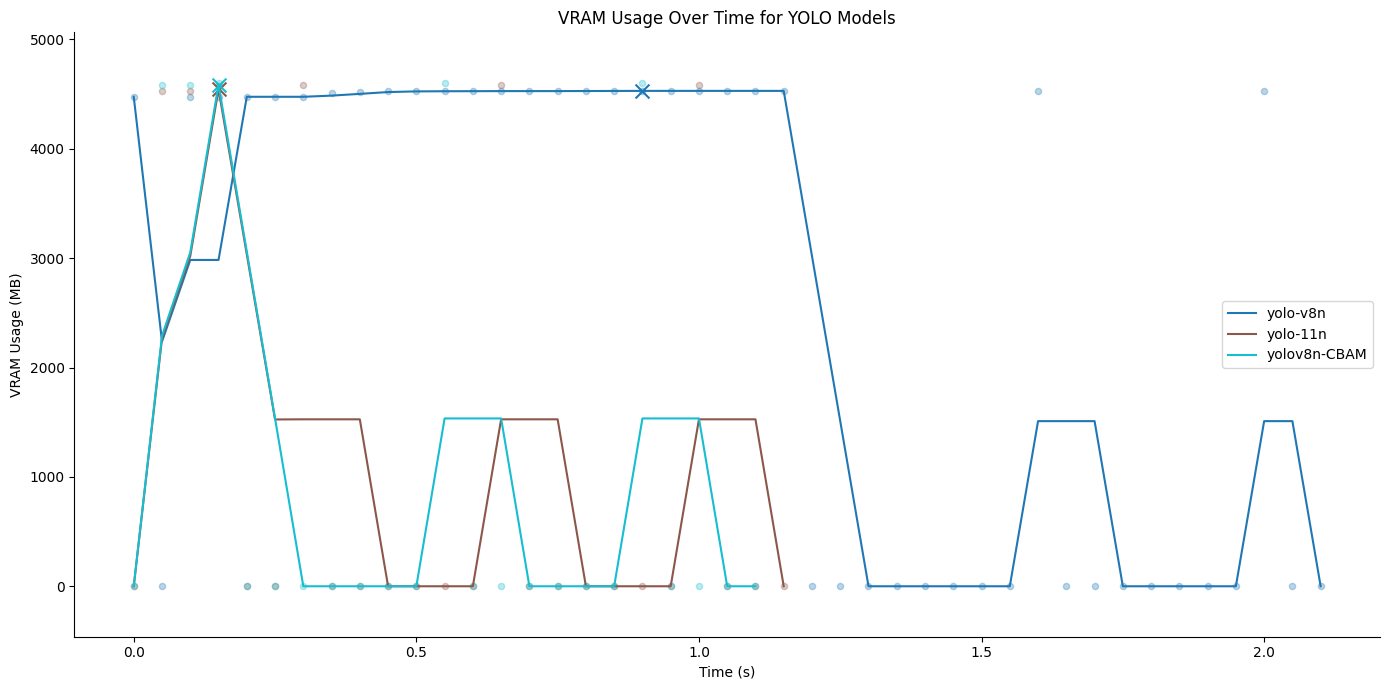

In [50]:
# # Usage
plot_all_models_vram(final_df)

In [51]:
import os, shutil

# Map original input → model name
model_name_map = {
    "/kaggle/input/aisummit-yolo-v8/runs/detect/train/weights/best.pt": "yolo-v8n",
    "/kaggle/input/aisummit-yolo-11n/runs/detect/train/weights/best.pt": "yolo-11n",
    "/kaggle/input/aisummit-improvedyolov8n/runs/detect/train/weights/best.pt": "yolov8n-CBAM"
}

work_dir = "/kaggle/working/quantized_models"
os.makedirs(work_dir, exist_ok=True)

# Copy models to /kaggle/working
local_paths = {}
for src, name in model_name_map.items():
    dst = os.path.join(work_dir, f"{name}.pt")
    shutil.copy(src, dst)
    local_paths[name] = dst
    print(f"✅ Copied {src} → {dst}")


✅ Copied /kaggle/input/aisummit-yolo-v8/runs/detect/train/weights/best.pt → /kaggle/working/quantized_models/yolo-v8n.pt
✅ Copied /kaggle/input/aisummit-yolo-11n/runs/detect/train/weights/best.pt → /kaggle/working/quantized_models/yolo-11n.pt
✅ Copied /kaggle/input/aisummit-improvedyolov8n/runs/detect/train/weights/best.pt → /kaggle/working/quantized_models/yolov8n-CBAM.pt


In [52]:
!pip install numpy==1.26.4 --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 79.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.3 which is incompatible.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you 

In [53]:
!yolo export model="/kaggle/working/quantized_models/yolo-v8n.pt" format=tflite int8=True project="/kaggle/working/quantized_models" name="yolo-v8n"
!yolo export model="/kaggle/working/quantized_models/yolo-11n.pt" format=tflite int8=True project="/kaggle/working/quantized_models" name="yolo-11n"
!yolo export model="/kaggle/working/quantized_models/yolov8n-CBAM.pt" format=tflite int8=True project="/kaggle/working/quantized_models" name="yolov8n-CBAM"


Ultralytics 8.3.220 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/kaggle/working/quantized_models/yolo-v8n.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 11, 2100) (5.9 MB)
E0000 00:00:1761263815.927148     852 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761263815.932824     852 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.

In [54]:
all_object_quant_csvs = []

model_paths = [
    "/kaggle/working/quantized_models/yolo-11n_saved_model/yolo-11n_int8.tflite",
    "/kaggle/working/quantized_models/yolo-v8n_saved_model/yolo-v8n_int8.tflite",
    "/kaggle/working/quantized_models/yolov8n-CBAM_saved_model/yolov8n-CBAM_int8.tflite"
]

class_names = ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

image_paths = [
    "/kaggle/input/aisummit-mobilenet-tl/data/test//biological/biological_104.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/cardboard/cardboard_2026.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/metal/metal_1147.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/glass/glass_1681.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/paper/paper_1039.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/plastic/plastic_1057.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/cardboard/cardboard_1626.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/trash/trash_255.jpg",
    "/kaggle/input/aisummit-mobilenet-tl/data/test/glass/glass_2375.jpg"
]

model_name_map = {
    "/kaggle/working/quantized_models/yolo-11n_saved_model/yolo-11n_int8.tflite": "yolo-v8n-quant",
    "/kaggle/working/quantized_models/yolo-v8n_saved_model/yolo-v8n_int8.tflite": "yolo-11n-quant",
    "/kaggle/working/quantized_models/yolov8n-CBAM_saved_model/yolov8n-CBAM_int8.tflite": "yolov8n-CBAM"
}

In [55]:
for model_path in model_paths:
    if model_path.endswith(".tflite"):
        # Get model name from full path
        model_name = model_name_map.get(model_path, os.path.basename(model_path))
        csv_file = f"{model_name}_benchmark.csv"
        print(f"Model Name: {model_name}")
        run_benchmark_yolo(model_path, image_paths, csv_file, model_name=model_name)
        all_object_quant_csvs.append(csv_file)


Model Name: yolo-v8n-quant
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Running inference for YOLO model: yolo-v8n-quant
Measuring RAM + VRAM usage of process 19 started.
[Profiler] before_biological_104.jpg: RAM=4907.91MB, VRAM=0.00MB
Loading /kaggle/working/quantized_models/yolo-11n_saved_model/yolo-11n_int8.tflite for TensorFlow Lite inference...
Image Path biological_104.jpg
[Profiler] after_biological_104.jpg: RAM=4915.54MB, VRAM=0.00MB
yolo-v8n-quant | /kaggle/input/aisummit-mobilenet-tl/data/test//biological/biological_104.jpg | time: 0.132s | pred: ['glass']
[Profiler] before_cardboard_2026.jpg: RAM=4915.54MB, VRAM=0.00MB
Image Path cardboard_2026.jpg
[Profiler] after_cardboard_2026.jpg: RAM=4915.79MB, VRAM=0.00MB
yolo-v8n-quant | /kaggle/input/aisummit-mobilenet-tl/data/test/cardboard/cardboard_2026.jpg | time: 0.039s | pred: ['cardboard']
[Profiler

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Image Path metal_1147.jpg
[Profiler] after_metal_1147.jpg: RAM=4915.79MB, VRAM=0.00MB
yolo-v8n-quant | /kaggle/input/aisummit-mobilenet-tl/data/test/metal/metal_1147.jpg | time: 0.034s | pred: ['metal']
[Profiler] before_glass_1681.jpg: RAM=4915.79MB, VRAM=0.00MB
Image Path glass_1681.jpg
[Profiler] after_glass_1681.jpg: RAM=4915.79MB, VRAM=0.00MB
yolo-v8n-quant | /kaggle/input/aisummit-mobilenet-tl/data/test/glass/glass_1681.jpg | time: 0.034s | pred: ['plastic']
[Profiler] before_paper_1039.jpg: RAM=4915.79MB, VRAM=0.00MB
Image Path paper_1039.jpg
[Profiler] after_paper_1039.jpg: RAM=4915.91MB, VRAM=0.00MB
yolo-v8n-quant | /kaggle/input/aisummit-mobilenet-tl/data/test/paper/paper_1039.jpg | time: 0.038s | pred: ['paper']
[Profiler] before_plastic_1057.jpg: RAM=4915.91MB, VRAM=0.00MB
Image Path plastic_1057.jpg
[Profiler] after_plastic_1057.jpg: RAM=4915.91MB, VRAM=0.00MB
yolo-v8n-quant | /kaggle/input/aisummit-mobilenet-tl/data/test/plastic/plastic_1057.jpg | time: 0.035s | pred: ['p

In [56]:
object_quant_dfs = []
for csv in all_object_quant_csvs:
    if os.path.exists(csv):
        ob_quant_df = pd.read_csv(csv)
        ob_quant_df["Model"] = os.path.basename(csv).replace("_benchmark.csv","")
        object_quant_dfs.append(ob_quant_df)

final_quant_df = pd.concat(object_quant_dfs, ignore_index=True)
final_quant_df.to_csv("all_models_quant_benchmark.csv", index=False)


In [57]:
final_quant_df

,Time,RAM_usage,VRAM_usage,Model
0,0.00,4907.91,0.00,yolo-v8n-quant
1,0.05,4913.54,4603.88,yolo-v8n-quant
2,0.10,4914.04,4603.88,yolo-v8n-quant
3,0.15,4915.41,4603.88,yolo-v8n-quant
4,0.20,4915.54,0.00,yolo-v8n-quant
...,...,...,...,...
99,2.25,4922.16,0.00,yolov8n-CBAM
100,2.30,4922.16,4603.88,yolov8n-CBAM
101,2.35,4922.16,4603.88,yolov8n-CBAM
102,2.40,4922.16,4603.88,yolov8n-CBAM


In [58]:
# Fix column names (remove spaces, lowercase, replace spaces with underscores)
final_quant_df.columns = final_quant_df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Cleaned columns:", final_quant_df.columns.tolist())


Cleaned columns: ['time', 'ram_usage', 'vram_usage', 'model']


In [59]:
ob_quant_df.columns = ob_quant_df.columns.str.strip().str.replace(" ", "_").str.lower()
print("Columns after cleaning:", ob_df.columns.tolist())

Columns after cleaning: ['time', 'ram_usage', 'vram_usage', 'model']


In [60]:
# Convert VRAM column to MB if needed
vram_col = "vram_usage"
if ob_quant_df[vram_col].dtype == object:
    ob_quant_df[vram_col] = ob_quant_df[vram_col].apply(mem_to_mb)

# Strip model names and remove .h5

In [61]:
# ---------------------------
# Multi-model plotting function
# ---------------------------
def plot_all_models_vram(ob_quant_df, vram_col="vram_usage", smooth_window=3, save_path="obj_detection_quant_models_vram.png"):
    fig, ax = plt.subplots(figsize=(14, 7))  # Use fig, ax for spines control

    # Generate unique colors for all models
    unique_models = ob_quant_df["model"].unique()
    colors = plt.cm.get_cmap("tab10", len(unique_models))

    for i, model in enumerate(unique_models):
        model_df = ob_quant_df[ob_quant_df["model"] == model].copy()
        # Apply rolling average
        model_df["VRAM_smooth"] = model_df[vram_col].rolling(window=smooth_window, min_periods=1).mean()
        model_df.loc[model_df.index[-1], "VRAM_smooth"] = 0

        model_label = model.replace(".h5", "")
        # Plot smoothed line
        ax.plot(model_df["time"], model_df["VRAM_smooth"], color=colors(i), label=f"{model_label}")
        # Plot original points lightly
        ax.scatter(model_df["time"], model_df[vram_col], color=colors(i), s=20, alpha=0.3)

        # Highlight peak
        peak_idx = model_df["VRAM_smooth"].idxmax()
        ax.scatter(model_df["time"][peak_idx], model_df["VRAM_smooth"][peak_idx],
                   color=colors(i), s=100, marker="x")

    # Dynamic y-axis
    min_mem = ob_quant_df[vram_col].min()
    max_mem = ob_quant_df[vram_col].max()
    margin = (max_mem - min_mem) * 0.1 + 1
    ax.set_ylim(min_mem - margin, max_mem + margin)

    # Labels and title
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("VRAM Usage (MB)")
    ax.set_title("VRAM Usage Over Time for YOLO Quantized Models")

    # Legend
    ax.legend()

    # Remove grid (already removed)
    # ax.grid(True)

    # Remove top and left spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

/tmp/ipykernel_19/488556901.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_models))


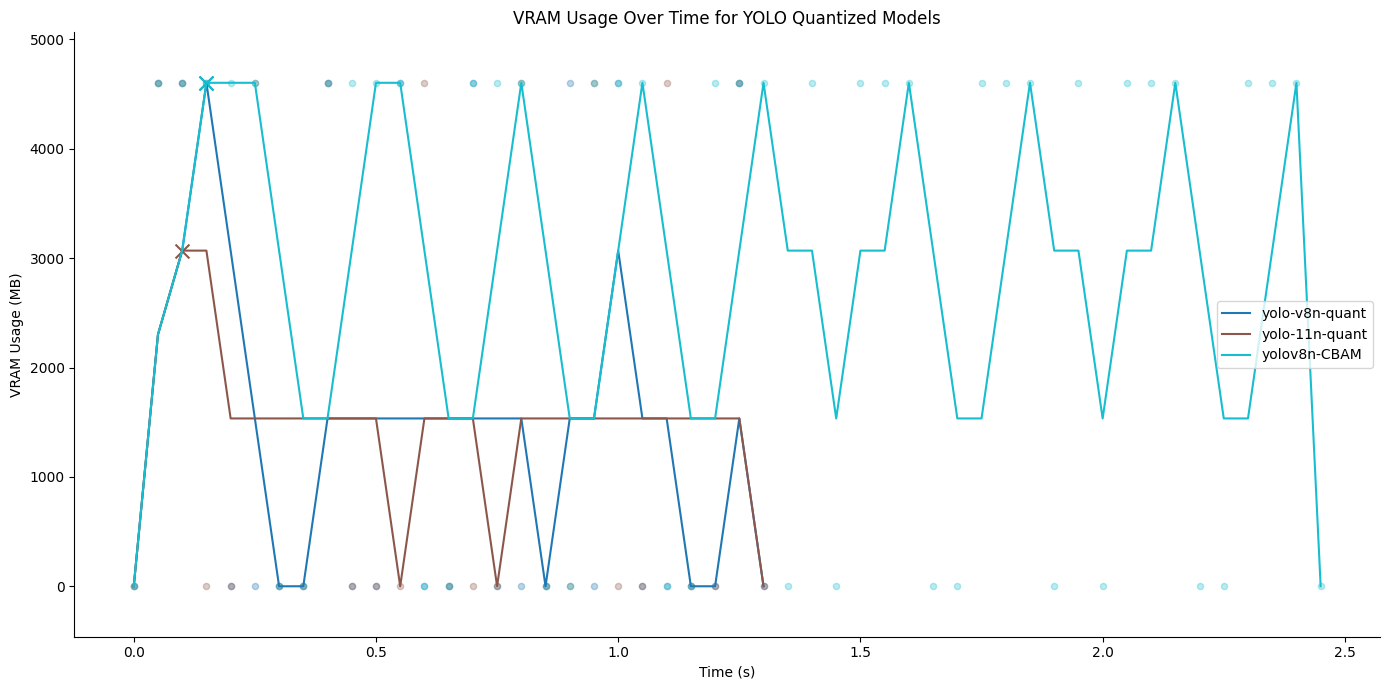

In [62]:
# # Usage
plot_all_models_vram(final_quant_df)